# Aim of the project - Building a Company Classifier for Insurance Taxonomy



Project Goal: Classify a list of companies into a taxonomy based on their provided data (description, tags, sector, etc)



Challenge: There is no pre-existing 'ground truth' to train traditional supervised model

## Problem-Solving Journey

I will explore 3 distinct approaches:


1. Approach 1: The Fuzzy Logic
 - A character-level mathcing attempt to find direct, literal string similarity

2. Approach 2: TF-IDF
 - A keyword-level matching method based on statistical word importance

3. Approach 3: SOTA (Semantic Transformers)
 - A concept-level matching method that understands the meaning and context of text

Finally, I will compare all three methods

## Fuzzy Logic


Why this choice?


My very first, intuitive attempt was to see if company descriptions, tags or sectors already contained the label names. Fuzzy Logic seems like a logical first step. It measures character-level similarity,


Trade-offs:
 - Upsides: Simple to understand. Requires no complex ML models

 - Downsideds: It has a zero undestanding of context. It would match "This company has nothing to do with Road Construction" just as strongly as "This company specializes in Road Consruction". Also it has no synonym supprt (e.g. "building roads" and "road construction" are treated as different.)

In [1]:
import pandas as pd


data1 = pd.read_csv('insurance_taxonomy - insurance_taxonomy.csv')
data2 = pd.read_csv('ml_insurance_challenge.csv')

In [2]:
data1['label']

,label
0,Agricultural Equipment Services
1,Soil Nutrient Application Services
2,Pesticide Application Services
3,Ornamental Plant Nurseries
4,Landscaping Services
...,...
215,Sports Management Services
216,Fitness Coaching
217,Health Promotion Services
218,Physical Therapy Services


In [3]:
print(data1.columns)

Index(['label'], dtype='object')


In [4]:
print(data2.columns)

Index(['description', 'business_tags', 'sector', 'category', 'niche'], dtype='object')


In [5]:
data1['label'] = data1['label'].astype(str).str.strip().str.lower()
data2['description'] = data2['description'].astype(str).str.strip().str.lower()

In [6]:
common_values = set(data2['description']).intersection(set(data1['label']))
print(f'Valori comune: {len(common_values)}')
print(list(common_values)[:10])


Valori comune: 0
[]


In [7]:
print("Descriptions:\n", data2['description'].head(10).to_list())
print("\nLabels:\n", data1['label'].head(10).to_list())

Descriptions:
 ['welchcivils is a civil engineering and construction company that specializes in designing and building utility network connections across the uk. they offer multi-utility solutions that combine electricity, gas, water, and fibre optic installation into a single contract. their design engineer teams are capable of designing electricity, water and gas networks from existing network connection points to meter locations at the development, as well as project management of reinforcements and diversions. they provide custom connection solutions that take into account any existing assets, maximize the usage of every trench, and meet project deadlines. welchcivils has considerable expertise installing gas and electricity connections in a variety of market categories, including residential, commercial, and industrial projects, as as well.', 'kyoto vegetable specialists uekamo, also known as iwa-machi, is a company based in kyoto, japan that specializes in the sale of vegetables

In [8]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 23.2 MB/s eta 0:00:00


In [9]:
import pandas as pd
from rapidfuzz import fuzz, process

data1 = pd.read_csv('insurance_taxonomy - insurance_taxonomy.csv')
data2 = pd.read_csv('ml_insurance_challenge.csv')

data1['label'] = data1['label'].astype(str).str.strip().str.lower()
data2['description'] = data2['description'].astype(str).str.strip().str.lower()

In [10]:
data1['label']

,label
0,agricultural equipment services
1,soil nutrient application services
2,pesticide application services
3,ornamental plant nurseries
4,landscaping services
...,...
215,sports management services
216,fitness coaching
217,health promotion services
218,physical therapy services


In [11]:
matches = []
for desc in data2['description']:
    match = process.extractOne(
        desc,
        data1['label'],
        scorer=fuzz.token_sort_ratio
    )
    if match:
        matches.append((desc, match[0], match[1]))

result = pd.DataFrame(matches, columns=['description', 'best_label_match', 'similarity_score'])
result = result[result['similarity_score'] > 50].sort_values(by='similarity_score', ascending=False)
print(result.head(10))

                                            description  \
3145  rn services is a computer hardware manufacture...   
4564  cuka shpk is a construction material wholesale...   
30    the company specializes in the professional in...   
3988  ck day trips is a transportation service company.   
7708  they also offer a usb microfone with a connector.   
1602  us services is a company that offers a range o...   

                                      best_label_match  similarity_score  
3145                     carpet manufacturing services         51.923077  
4564                  low-rise foundation construction         51.546392  
30    residential communication equipment installation         50.704225  
3988                        sports management services         50.666667  
7708            roofing services with heat application         50.574713  
1602            roofing services with heat application         50.526316  


In [12]:
result.to_csv('fuzzy_matched_results.csv', index=False)

In [14]:
results_df = pd.read_csv('fuzzy_matched_results.csv')
results_df.head()

,description,best_label_match,similarity_score
0,rn services is a computer hardware manufacture...,carpet manufacturing services,51.923077
1,cuka shpk is a construction material wholesale...,low-rise foundation construction,51.546392
2,the company specializes in the professional in...,residential communication equipment installation,50.704225
3,ck day trips is a transportation service company.,sports management services,50.666667
4,they also offer a usb microfone with a connector.,roofing services with heat application,50.574713


## Results Fuzzy Logic:

Low similarity scores and matches are poor and few.

## TF-IDF and Cosine Similarity

Why this method?

Since character-level matching failed Imoved to word-level similarity. TF-IDF is fast and measures the statistical importance of a word


How it Works:

 - The "Trick":  I fit the vectorizer only on the taxonomy labels. This creates a vocab of words relevant to the insurance industry (e.g. 'constructiin', 'road', 'financial', 'services')

 - I then transform the company descriptions using the same vocab

 - I use Cosine Similarity to find the closest vector match.


 Trade-offs
  - Upsides: Good at finding exact keyword matches.

  - Downsides: 'Lexically stupid' meaning no understanding of synonyms (e.g. 'car repair' and 'auto body shop' as treated completly different). It will get a score of 0.0 if a company description uses relevant words that just happen not to be in the taxonomy's labels

In [15]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
print("CSVs files:")
try:
  companies_df = pd.read_csv('ml_insurance_challenge.csv')
  taxonomy_df = pd.read_csv('insurance_taxonomy - insurance_taxonomy.csv')
except FileNotFoundError as e:
  print("Error: File not found. {e}")
  exit()
print(f"Files {len(companies_df)} - compaines and {len(taxonomy_df)} - labels")

CSVs files:
Files 9494 - compaines and 220 - labels


## Feature Engineering: Creating a "Document" for Each Company


Both approaches (TF-IDF and Zero-Shot) require a single, clean text field to represent each company. I'll combine the most descriptive fields (description, business_tags, sector, category, niche) into a new column called combined_text. This will be our 'document'.

In [17]:
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'\[.*?\]', '', text)
  text = re.sub(r'[^a-z0-9\s]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

In [18]:
taxonomy_df['label_cleaned'] = taxonomy_df['label'].apply(clean_text)
text_columns = ['description', 'business_tags', 'sector', 'category', 'niche']
for col in text_columns:
  companies_df[col] = companies_df[col].fillna('')

In [19]:
companies_df['combined_text'] = companies_df['description'].apply(clean_text) + ' ' + companies_df['business_tags'].apply(clean_text) + ' ' + companies_df['sector'].apply(clean_text) + ' ' + companies_df['category'].apply(clean_text) + ' ' + companies_df['niche'].apply(clean_text)

In [20]:
original_labels = taxonomy_df['label'].tolist()
cleaned_labels = taxonomy_df['label_cleaned'].tolist()

In [21]:
print("Combined text:\n")
print(companies_df['combined_text'].head(1).values[0])

Combined text:

welchcivils is a civil engineering and construction company that specializes in designing and building utility network connections across the uk they offer multiutility solutions that combine electricity gas water and fibre optic installation into a single contract their design engineer teams are capable of designing electricity water and gas networks from existing network connection points to meter locations at the development as well as project management of reinforcements and diversions they provide custom connection solutions that take into account any existing assets maximize the usage of every trench and meet project deadlines welchcivils has considerable expertise installing gas and electricity connections in a variety of market categories including residential commercial and industrial projects as as well  services civil engineering services other heavy and civil engineering construction


In [22]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    analyzer='word',
    ngram_range=(1, 2)
)

In [23]:
label_tfidf = vectorizer.fit_transform(cleaned_labels)

print(f"Shape of label_tfidf: {label_tfidf.shape}")
print(f"TF-IDF Vocab size: {len(vectorizer.get_feature_names_out())}")

Shape of label_tfidf: (220, 575)
TF-IDF Vocab size: 575


In [24]:
print("Transform compaines text to TF-IDF vectors")
company_tfidf = vectorizer.transform(companies_df['combined_text'])
print(f"Shape of company_tfidf: {company_tfidf.shape}")

Transform compaines text to TF-IDF vectors
Shape of company_tfidf: (9494, 575)


In [25]:
print(f"Calculate similarity matrix")
similarity_matrix = cosine_similarity(company_tfidf, label_tfidf)
print(f"Shape of similarity matrix: {similarity_matrix.shape}")

print(f"Extracting the best match for each company:")
best_match_indices = np.argmax(similarity_matrix, axis=1)
best_match_scores = np.max(similarity_matrix, axis=1)

Calculate similarity matrix
Shape of similarity matrix: (9494, 220)
Extracting the best match for each company:


In [26]:
companies_df['insurance_label'] = [original_labels[i] for i in best_match_indices]
companies_df['similarity_score'] = best_match_scores

In [27]:
output_filename = 'annotated_company_list_tfidf.csv'
print(f"\n Saving the results in {output_filename}")
companies_df.to_csv(output_filename, index=False)
print("Operațiune finalizată!")
print("\n--- Cele mai bune 10 potriviri TF-IDF găsite ---")
print(companies_df.sort_values(by='similarity_score', ascending=False)[['description', 'insurance_label', 'similarity_score']].head(10))

print("\n--- Cele mai slabe 10 potriviri TF-IDF găsite (scor 0.0) ---")
print(companies_df.sort_values(by='similarity_score', ascending=True)[['description', 'insurance_label', 'similarity_score']].head(10))


 Saving the results in annotated_company_list_tfidf.csv
Operațiune finalizată!

--- Cele mai bune 10 potriviri TF-IDF găsite ---
                                            description  \
6198  Anita Borkowska-Moskalik is a lawyer and court...   
7655  The Memphis Municipal Employee FCU is a federa...   
2929  XE is a company that provides a free live curr...   
3978  Rent A Car In Portugal is a company that speci...   
1336  Flyer La Palma is a company that offers mini f...   
2002  Wahab Meubel is a company based in Tegal, Cent...   
8055  KAKAWI CACAO SPIRIT is a chocolate factory loc...   
120   Brownie It's Cacau is a company that specializ...   
6525  Ideas Marbella - Interiorismo y Decoración is ...   
5472  Izdeliya Iz Silikona is a company based in Vla...   

                  insurance_label  similarity_score  
6198               Legal Services          1.000000  
7655           Financial Services          0.986744  
2929           Financial Services          0.986744  
3978

In [44]:
tfidf_ds = pd.read_csv('annotated_company_list_tfidf.csv')
tfidf_ds.head()

,description,business_tags,sector,category,niche,combined_text,insurance_label,similarity_score
0,Welchcivils is a civil engineering and constru...,"['Construction Services', 'Multi-utilities', '...",Services,Civil Engineering Services,Other Heavy and Civil Engineering Construction,welchcivils is a civil engineering and constru...,Project Management Services,0.406886
1,"Kyoto Vegetable Specialists Uekamo, also known...","['Wholesale', 'Dual-task Movement Products', '...",Manufacturing,Fruit & Vegetable - Markets & Stores,"Frozen Fruit, Juice, and Vegetable Manufacturing",kyoto vegetable specialists uekamo also known ...,Media Production Services,0.232644
2,Loidholdhof Integrative Hofgemeinschaft is a c...,"['Living Forms', 'Farm Cafe', 'Fresh Coffee', ...",Manufacturing,Farms & Agriculture Production,All Other Miscellaneous Crop Farming,loidholdhof integrative hofgemeinschaft is a c...,Quality Assurance Services,0.391184
3,PATAGONIA Chapa Y Pintura is an auto body shop...,"['Automotive Body Repair Services', 'Interior ...",Services,Auto Body Shops,"Automotive Body, Paint, and Interior Repair an...",patagonia chapa y pintura is an auto body shop...,Boiler Repair Services,0.595011
4,Stanica WODNA PTTK Swornegacie is a cultural e...,"['Cultural Activities', 'Accommodation Service...",Services,Boat Tours & Cruises,"Scenic and Sightseeing Transportation, Water",stanica wodna pttk swornegacie is a cultural e...,Water Treatment Services,0.519974


## Similarity scores histogram

 - X-axis - points to match score, from 0.0(no match) to 1.0 (perfect match)

 - Y-axis - how many comapnies have obtained the score

 - Blue curve - general distribution

 - Red line - Mean



--- Se generează vizualizările (Seaborn) pentru TF-IDF ---
Se generează Graficul 1: Distribuția Scorurilor (TF-IDF)...
Graficul 1 (distribuția scorurilor) a fost salvat ca 'tfidf_similarity_distribution.png'


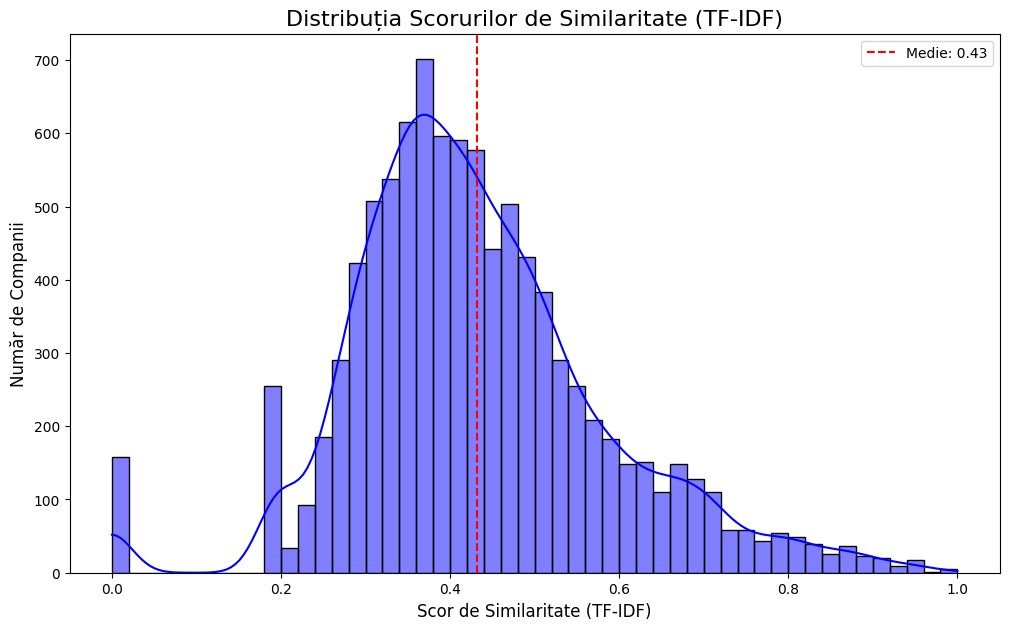

In [28]:
print("\n--- Se generează vizualizările (Seaborn) pentru TF-IDF ---")
print("Se generează Graficul 1: Distribuția Scorurilor (TF-IDF)...")
plt.figure(figsize=(12, 7))
sns.histplot(companies_df['similarity_score'], bins=50, kde=True, color='blue')
plt.title('Distribuția Scorurilor de Similaritate (TF-IDF)', fontsize=16)
plt.xlabel('Scor de Similaritate (TF-IDF)', fontsize=12)
plt.ylabel('Număr de Companii', fontsize=12)
plt.axvline(companies_df['similarity_score'].mean(), color='red', linestyle='--', label=f'Medie: {companies_df["similarity_score"].mean():.2f}')
plt.legend()
plt.savefig('tfidf_similarity_distribution.png')
print("Graficul 1 (distribuția scorurilor) a fost salvat ca 'tfidf_similarity_distribution.png'")

## Most Frequent Labels


This chart displays the most frequently assigned labels by the model


How to read it?
The longest bar represents the category that appears most often in our list.

Se generează Graficul 2: Top 20 Etichete (Brut, TF-IDF)...


/tmp/ipython-input-786766139.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Graficul 2 (top 20 etichete brut) a fost salvat ca 'tfidf_top_20_labels_barchart.png'


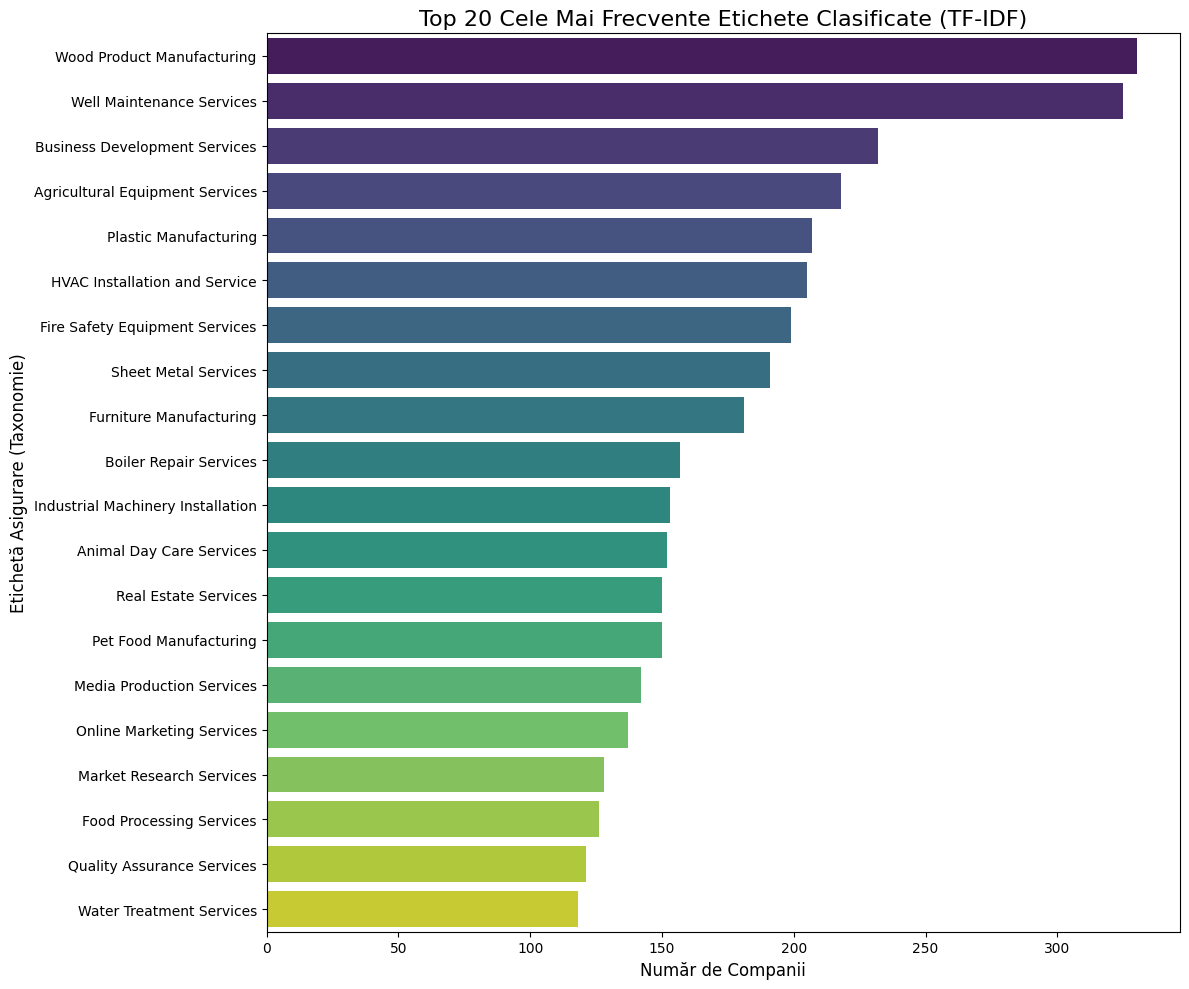

In [29]:
print("Se generează Graficul 2: Top 20 Etichete (Brut, TF-IDF)...")
plt.figure(figsize=(12, 10))

top_20_labels = companies_df['insurance_label'].value_counts().nlargest(20).index
df_top_20 = companies_df[companies_df['insurance_label'].isin(top_20_labels)]

sns.countplot(
    data=df_top_20,
    y='insurance_label',
    order=top_20_labels,
    palette='viridis'
)
plt.title('Top 20 Cele Mai Frecvente Etichete Clasificate (TF-IDF)', fontsize=16)
plt.xlabel('Număr de Companii', fontsize=12)
plt.ylabel('Etichetă Asigurare (Taxonomie)', fontsize=12)
plt.tight_layout()
plt.savefig('tfidf_top_20_labels_barchart.png')
print("Graficul 2 (top 20 etichete brut) a fost salvat ca 'tfidf_top_20_labels_barchart.png'")

## Top Labels with Confidence Threshold


Similar as the previous plot but after filtering out all low-confidence matches.


How to read it?
This represents the 'true' distribution companies of relevant, classifiable companie in the dataset. It answers the question: "Of the companies that actually fit our taxonomy, what do they do?"

Se generează Graficul 3: Top 20 Etichete 'Curățat' (TF-IDF)...
Se folosește un prag de încredere de > 0.1


/tmp/ipython-input-1779203847.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Graficul 3 (top 20 etichete 'curățate') a fost salvat ca 'tfidf_top_20_labels_cleaned.png'

--- Toate operațiunile TF-IDF, inclusiv vizualizările, au fost finalizate. ---


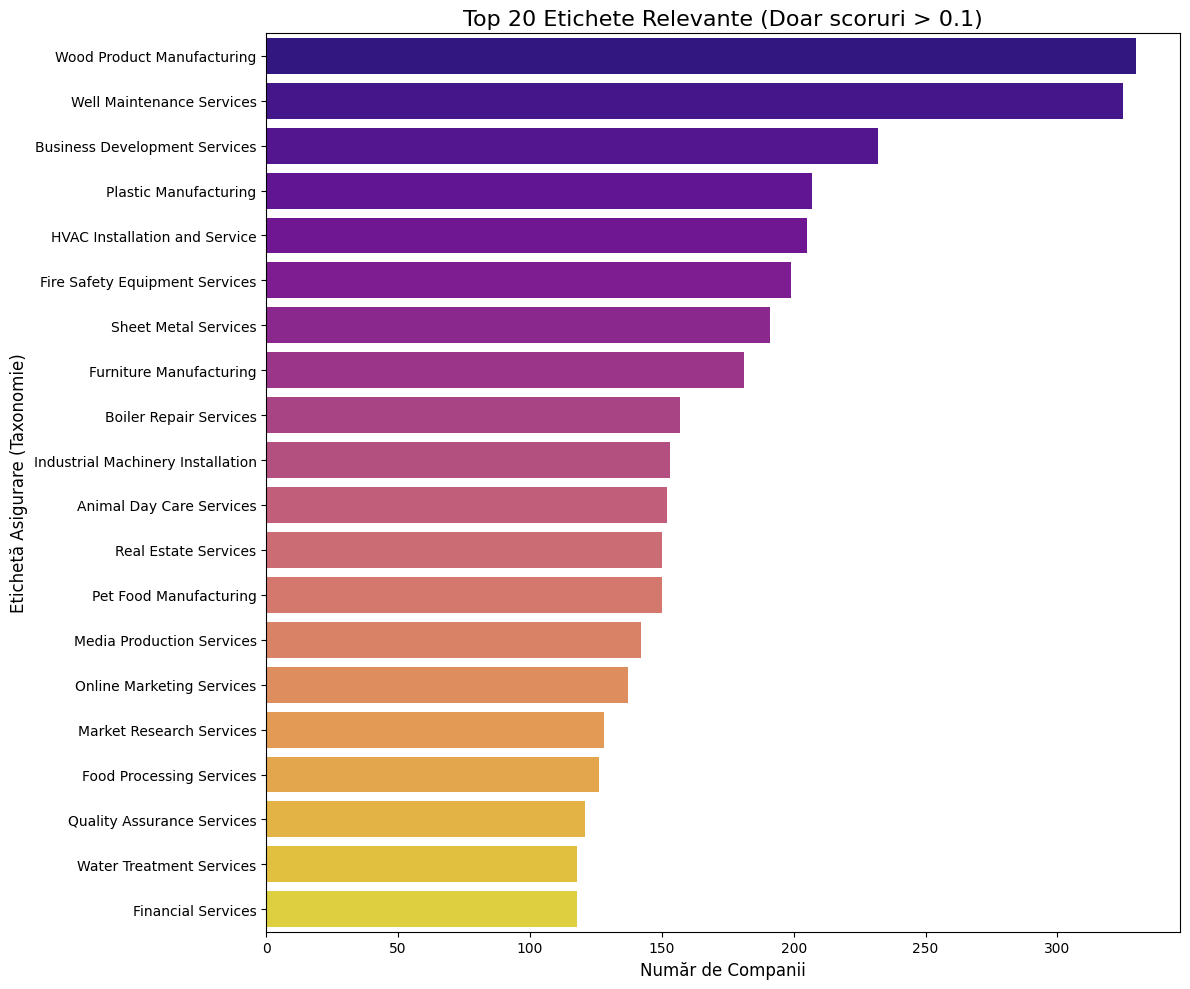

In [30]:
print("Se generează Graficul 3: Top 20 Etichete 'Curățat' (TF-IDF)...")
threshold = 0.1
print(f"Se folosește un prag de încredere de > {threshold}")

df_confident = companies_df[companies_df['similarity_score'] >= threshold]

if not df_confident.empty:
    plt.figure(figsize=(12, 10))

    top_20_labels_confident = df_confident['insurance_label'].value_counts().nlargest(20).index
    df_top_20_confident = df_confident[df_confident['insurance_label'].isin(top_20_labels_confident)]

    sns.countplot(
        data=df_top_20_confident,
        y='insurance_label',
        order=top_20_labels_confident,
        palette='plasma'
    )
    plt.title(f'Top 20 Etichete Relevante (Doar scoruri > {threshold})', fontsize=16)
    plt.xlabel('Număr de Companii', fontsize=12)
    plt.ylabel('Etichetă Asigurare (Taxonomie)', fontsize=12)
    plt.tight_layout()
    plt.savefig('tfidf_top_20_labels_cleaned.png')
    print("Graficul 3 (top 20 etichete 'curățate') a fost salvat ca 'tfidf_top_20_labels_cleaned.png'")
else:
    print(f"Nu a fost găsită nicio companie cu un scor de similaritate peste {threshold}. Graficul 3 nu a fost generat.")

print("\n--- Toate operațiunile TF-IDF, inclusiv vizualizările, au fost finalizate. ---")

## Conclusion TF-IDF

There is a clear improvement like logical matches, however, the 'worst matches' table reveals an important flaw: a spike of 0.0 scores. These companies that don;t share any keyword with the taxonomy.

## Zero-Shot Classification


Why this method?

I use a pre-trained model that understands English at a deep, semantic level.

1. The model turns each label (e.g. 'Road Construction') into a dimension vector representing its meaning.

2. It does the same for each company description

3. The I use Cosine Similarity to find the closest semantic mathc.


Trade-offs:

  - Upsides: Understand synonyms, context and nunace. It solves the actual problem.

  - Downised: Computationally more expenisve than TF-IDF. It is much slower without a GPU



In [31]:
!pip install -U sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.0/488.0 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: sentence_transformers
    Found existing installation: sentence-transformers 5.1.1
    Uninstalling sentence-transformers-5.1.1:
      Successfully uninstalled sentence-transformers-5.1.1


In [32]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
try:
  companies_df = pd.read_csv('ml_insurance_challenge.csv')
  taxonomy_df = pd.read_csv('insurance_taxonomy - insurance_taxonomy.csv')
except FileNotFoundError as e:
  print(f"Error: File not found. {e}")
  exit()
print(f"Files {len(companies_df)} - compaines and {len(taxonomy_df)} - labels")

Files 9494 - compaines and 220 - labels


In [35]:
text_columns = ['description', 'business_tags', 'sector', 'category', 'niche']
for col in text_columns:
  companies_df[col] = companies_df[col].fillna('')

companies_df['combined_text'] = companies_df['description'] + ' ' + companies_df['business_tags'] + ' ' + companies_df['sector'] + ' ' + companies_df['category'] + ' ' + companies_df['niche']
labels = taxonomy_df['label'].tolist()

print('Combined text:\n')
print(companies_df['combined_text'].head(1).values[0])

Combined text:

Welchcivils is a civil engineering and construction company that specializes in designing and building utility network connections across the UK. They offer multi-utility solutions that combine electricity, gas, water, and fibre optic installation into a single contract. Their design engineer teams are capable of designing electricity, water and gas networks from existing network connection points to meter locations at the development, as well as project management of reinforcements and diversions. They provide custom connection solutions that take into account any existing assets, maximize the usage of every trench, and meet project deadlines. Welchcivils has considerable expertise installing gas and electricity connections in a variety of market categories, including residential, commercial, and industrial projects, as as well. ['Construction Services', 'Multi-utilities', 'Utility Network Connections Design and Construction', 'Water Connection Installation', 'Multi-ut

In [36]:
try:
  model = SentenceTransformer('all-MiniLM-L6-v2')
except Exception as e:
  print(f"Error loading model: {e}")
  exit()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [37]:
company_embeddings = model.encode(companies_df['combined_text'].tolist(), show_progress_bar=True)
label_embeddings = model.encode(labels, show_progress_bar=True)
print(f"Shape of company embeddings: {company_embeddings.shape}")
print(f"Label embeddings: {label_embeddings.shape}")

Batches:   0%|          | 0/297 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Shape of company embeddings: (9494, 384)
Label embeddings: (220, 384)


In [38]:
simirarity_matrix = cosine_similarity(company_embeddings, label_embeddings)
print(f"Similarity matrix shape: {simirarity_matrix.shape}")

Similarity matrix shape: (9494, 220)


In [39]:
print("Extracting the best match for every company\n")
best_match_indices = np.argmax(simirarity_matrix, axis=1)
best_match_scores = np.max(simirarity_matrix, axis=1)

companies_df['insurance_label'] = [labels[i] for i in best_match_indices]
companies_df['similarity_score'] = best_match_scores

Extracting the best match for every company



In [40]:
output_filename = 'annotated_company_list_semantic.csv'
companies_df.to_csv(output_filename, index=False)

print("\n --- The best 10 matches are --- \n")
print(companies_df.sort_values(by='similarity_score', ascending=False)[['description', 'insurance_label', 'similarity_score']].head(10))

print("\n --- The worst 10 matches are --- \n")
print(companies_df.sort_values(by='similarity_score', ascending=True)[['description', 'insurance_label', 'similarity_score']].head(10))


 --- The best 10 matches are --- 

                                            description  \
4234  The company is a professional tent company bas...   
5113  The company specializes in the production and ...   
5214  Leading Fire and Security Systems is a company...   
5584  WM (formerly Waste Management) is a waste mana...   
4682  5V Welding Services is a company that provides...   
4181  Construction Cleaning is a company that specia...   
4009  The company is a group of experienced and pass...   
1852  Lift Production Bakery Ltd is a bakery company...   
4226  Gate City Recycling is a business-to-business ...   
106   They specialize in providing comprehensive ser...   

                     insurance_label  similarity_score  
4234     Tent Manufacturing Services          0.764824  
5113         Furniture Manufacturing          0.754785  
5214  Fire Safety Equipment Services          0.745745  
5584       Waste Management Services          0.742792  
4682                Welding S

In [45]:
zero_shot_ds = pd.read_csv('annotated_company_list_semantic.csv')
zero_shot_ds.head()

,description,business_tags,sector,category,niche,combined_text,insurance_label,similarity_score
0,Welchcivils is a civil engineering and constru...,"['Construction Services', 'Multi-utilities', '...",Services,Civil Engineering Services,Other Heavy and Civil Engineering Construction,Welchcivils is a civil engineering and constru...,Commercial Construction Services,0.454291
1,"Kyoto Vegetable Specialists Uekamo, also known...","['Wholesale', 'Dual-task Movement Products', '...",Manufacturing,Fruit & Vegetable - Markets & Stores,"Frozen Fruit, Juice, and Vegetable Manufacturing","Kyoto Vegetable Specialists Uekamo, also known...",Food Processing Services,0.397987
2,Loidholdhof Integrative Hofgemeinschaft is a c...,"['Living Forms', 'Farm Cafe', 'Fresh Coffee', ...",Manufacturing,Farms & Agriculture Production,All Other Miscellaneous Crop Farming,Loidholdhof Integrative Hofgemeinschaft is a c...,Bakery Production Services,0.576987
3,PATAGONIA Chapa Y Pintura is an auto body shop...,"['Automotive Body Repair Services', 'Interior ...",Services,Auto Body Shops,"Automotive Body, Paint, and Interior Repair an...",PATAGONIA Chapa Y Pintura is an auto body shop...,Pallet Manufacturing,0.360132
4,Stanica WODNA PTTK Swornegacie is a cultural e...,"['Cultural Activities', 'Accommodation Service...",Services,Boat Tours & Cruises,"Scenic and Sightseeing Transportation, Water",Stanica WODNA PTTK Swornegacie is a cultural e...,Canning Services,0.236038


## Similarity scores histogram

Similar to the TF-IDF histogram but:

 - 0.0 spike has vanished
 - the curve is centerd around 0.4

This means the semantic model never faield. Even for the most irrelevant company, the model still found a match.

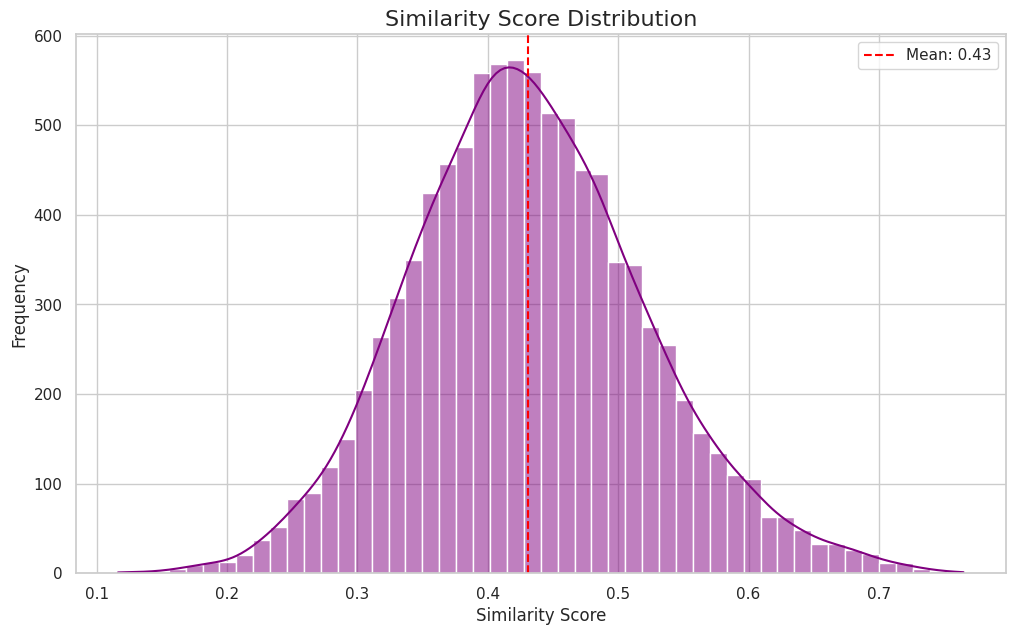

In [41]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 7))
sns.histplot(companies_df['similarity_score'], bins=50, kde=True, color='purple')
plt.title('Similarity Score Distribution', fontsize=16)
plt.xlabel('Similarity Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(companies_df['similarity_score'].mean(), color='red', linestyle='--', label=f'Mean: {companies_df["similarity_score"].mean():.2f}')
plt.legend()
plt.savefig('semantic_similarity_distribution.png')
plt.show()

## Most Frequent Labels


This chart displays the most frequently assigned labels by the model


How to read it?
The longest bar represents the category that appears most often in our list.

Se generează Graficul 2: Top 20 Etichete (Brut)...


/tmp/ipython-input-2019510492.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Graficul 2 (top 20 etichete brut) a fost salvat ca 'semantic_top_20_labels_barchart.png'


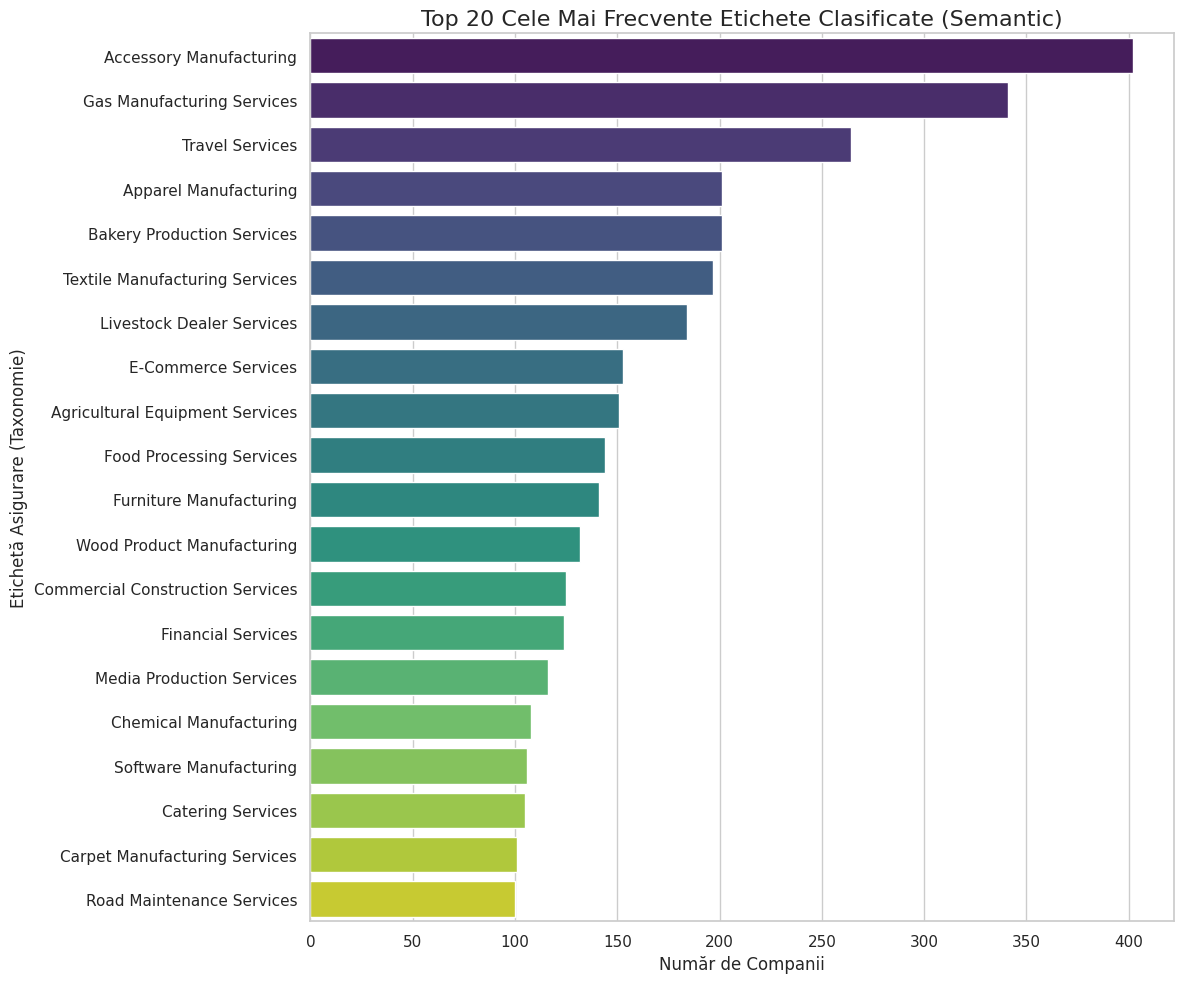

In [42]:
print("Se generează Graficul 2: Top 20 Etichete (Brut)...")
plt.figure(figsize=(12, 10))

top_20_labels = companies_df['insurance_label'].value_counts().nlargest(20).index
df_top_20 = companies_df[companies_df['insurance_label'].isin(top_20_labels)]

sns.countplot(
    data=df_top_20,
    y='insurance_label',
    order=top_20_labels,
    palette='viridis'
)
plt.title('Top 20 Cele Mai Frecvente Etichete Clasificate (Semantic)', fontsize=16)
plt.xlabel('Număr de Companii', fontsize=12)
plt.ylabel('Etichetă Asigurare (Taxonomie)', fontsize=12)
plt.tight_layout()
plt.savefig('semantic_top_20_labels_barchart.png')
print("Graficul 2 (top 20 etichete brut) a fost salvat ca 'semantic_top_20_labels_barchart.png'")

## Top Labels with Confidence Threshold


Similar as the previous plot but after filtering out all low-confidence matches.


How to read it?
This represents the 'true' distribution companies of relevant, classifiable companie in the dataset. It answers the question: "Of the companies that actually fit our taxonomy, what do they do?"

Se generează Graficul 3: Top 20 Etichete 'Curățat' (Prag de Încredere)...
Se folosește un prag de încredere de > 0.3


/tmp/ipython-input-1145316923.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Graficul 3 (top 20 etichete 'curățate') a fost salvat ca 'semantic_top_20_labels_cleaned.png'

--- Toate operațiunile, inclusiv vizualizările, au fost finalizate. ---


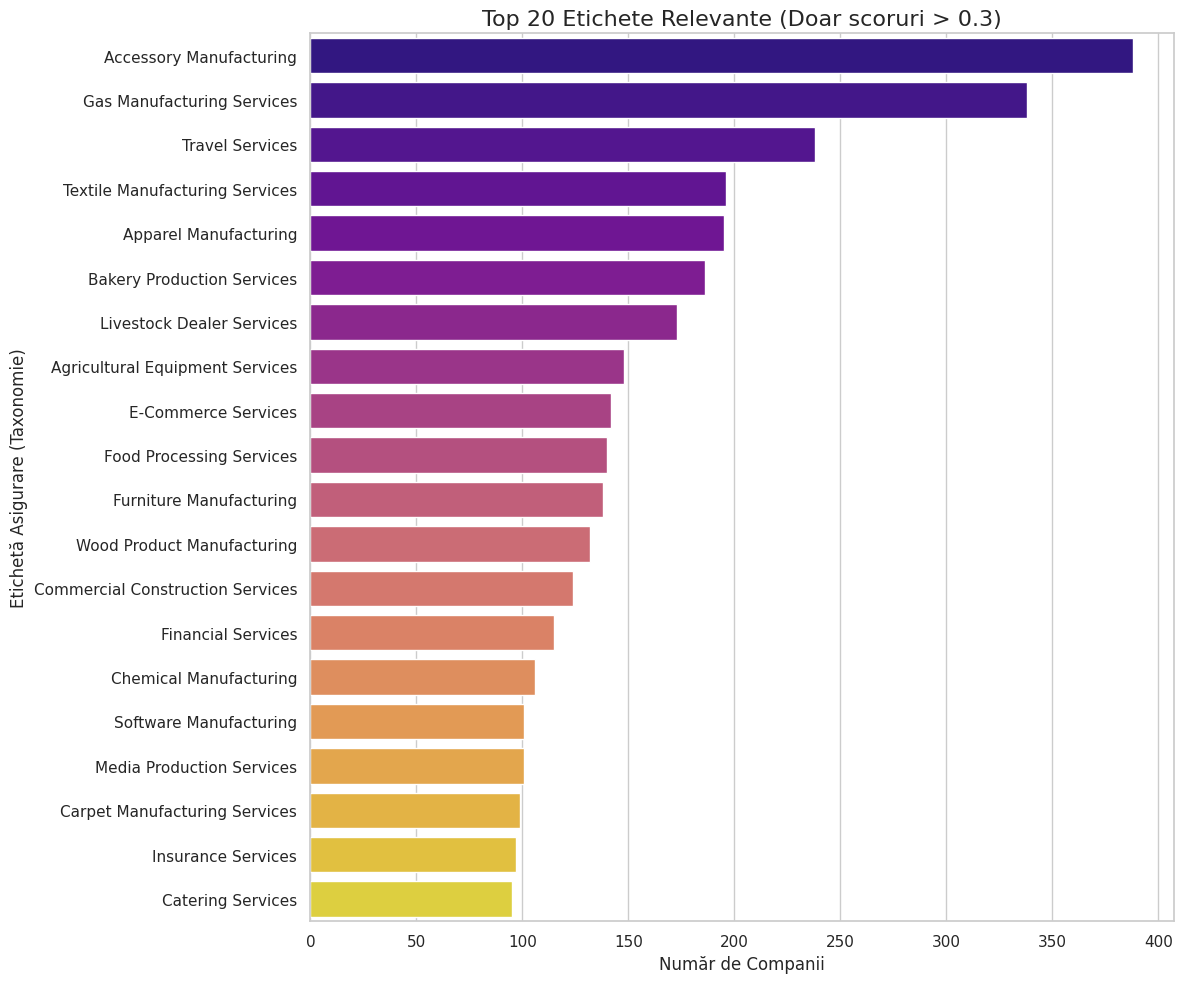

In [43]:
print("Se generează Graficul 3: Top 20 Etichete 'Curățat' (Prag de Încredere)...")
threshold = 0.3
print(f"Se folosește un prag de încredere de > {threshold}")

df_confident = companies_df[companies_df['similarity_score'] >= threshold]

if not df_confident.empty:
    plt.figure(figsize=(12, 10))

    top_20_labels_confident = df_confident['insurance_label'].value_counts().nlargest(20).index
    df_top_20_confident = df_confident[df_confident['insurance_label'].isin(top_20_labels_confident)]

    sns.countplot(
        data=df_top_20_confident,
        y='insurance_label',
        order=top_20_labels_confident,
        palette='plasma'
    )
    plt.title(f'Top 20 Etichete Relevante (Doar scoruri > {threshold})', fontsize=16)
    plt.xlabel('Număr de Companii', fontsize=12)
    plt.ylabel('Etichetă Asigurare (Taxonomie)', fontsize=12)
    plt.tight_layout()
    plt.savefig('semantic_top_20_labels_cleaned.png')
    print("Graficul 3 (top 20 etichete 'curățate') a fost salvat ca 'semantic_top_20_labels_cleaned.png'")
else:
    print(f"Nu a fost găsită nicio companie cu un scor de similaritate peste {threshold}. Graficul 3 nu a fost generat.")

print("\n--- Toate operațiunile, inclusiv vizualizările, au fost finalizate. ---")

## Conclusion using Zero-Shot


This is the best method. Even the lower scores are never zero.

## Models Comparison


In [46]:
df_tfidf_results = pd.read_csv('annotated_company_list_tfidf.csv')
df_semantic_results = pd.read_csv('annotated_company_list_semantic.csv')
df_fuzzy_results_merged = pd.merge(companies_df[['description']], results_df, on='description', how='left')
df_compare = pd.DataFrame({
    'description': companies_df['description'],
    'label_fuzzy': df_fuzzy_results_merged['best_label_match'],
    'score_fuzzy': df_fuzzy_results_merged['similarity_score'] / 100,
    'label_tfidf': df_tfidf_results['insurance_label'],
    'score_tfidf': df_tfidf_results['similarity_score'],
    'label_semantic': df_semantic_results['insurance_label'],
    'score_semantic': df_semantic_results['similarity_score']
})
print("--- Statistical Comparison of All 3 Methods ---")
display(df_compare[['score_fuzzy', 'score_tfidf', 'score_semantic']].describe())

--- Statistical Comparison of All 3 Methods ---


,score_fuzzy,score_tfidf,score_semantic
count,0.0,9494.000000,9494.000000
mean,NaN,0.431978,0.431197
std,NaN,0.151906,0.091040
min,NaN,0.000000,0.116436
25%,NaN,0.336435,0.369706
50%,NaN,0.412197,0.427131
75%,NaN,0.510616,0.488175
max,NaN,1.000000,0.764824


## Model 'Confidence' Distribution (Histogram)


How to read it

 - A bar on the right (near 1.0) means many 'high confidence' matches.

 - A bar on the left (near 0.0) means many 'low confidence' or 'failed' matches.

 - We are looking for a 'normal' distribution which shows the model is discerning bewteen good and bad matches

/tmp/ipython-input-3232883866.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_compare['score_fuzzy'], label='Fuzzy Logic', color='red', fill=True, alpha=0.1)


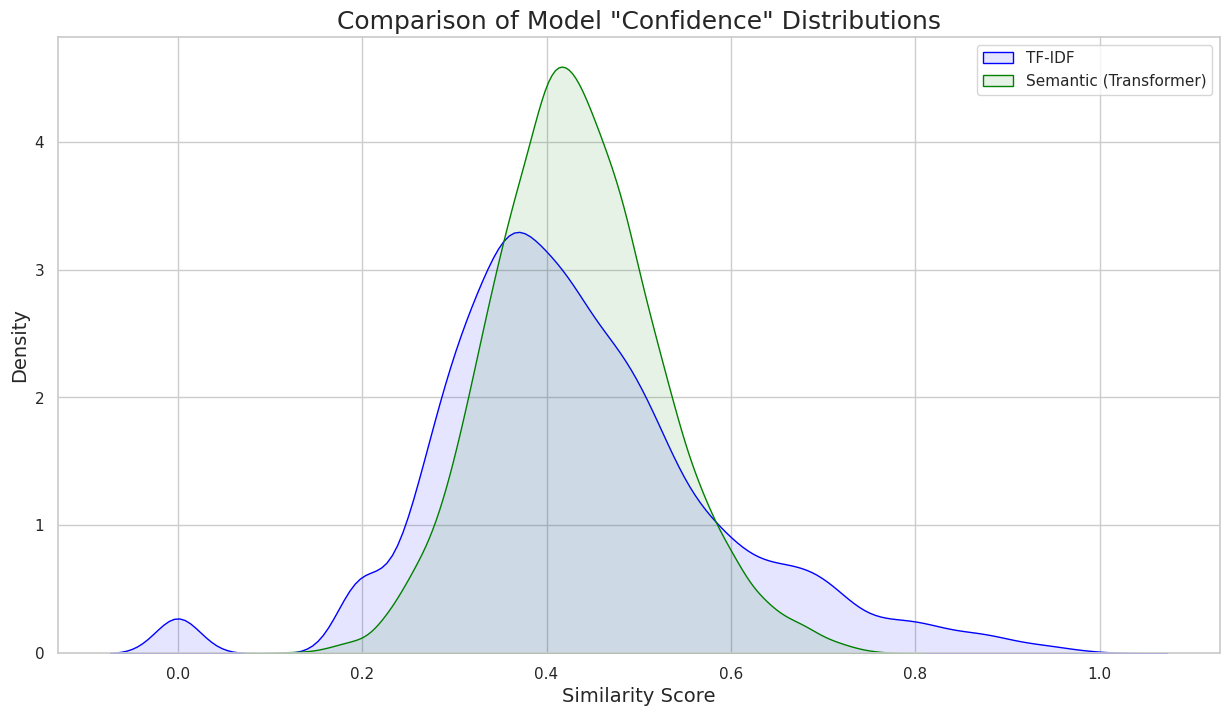

In [47]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8))

sns.kdeplot(df_compare['score_fuzzy'], label='Fuzzy Logic', color='red', fill=True, alpha=0.1)
sns.kdeplot(df_compare['score_tfidf'], label='TF-IDF', color='blue', fill=True, alpha=0.1)
sns.kdeplot(df_compare['score_semantic'], label='Semantic (Transformer)', color='green', fill=True, alpha=0.1)

plt.title('Comparison of Model "Confidence" Distributions', fontsize=18)
plt.xlabel('Similarity Score', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.savefig('all_distributions_kde.png')
plt.show()

So there is no Fuzzy Logic in the plot. This is a clear visualization that fuzzy can't make matches and is unable to see a good match and a bad match.


Also we can see for TF-IDF some spikes at 0.0 and a clear clue that it was unable to classify a good portion of the companies.

Zero-Shot - normal looking curve, no spike at 0, centered around 0.4-0.5, showing it finds 'reasonable' matches for most companies.

## Final Conclusions


This project served as a comprehensive exploration of methodologies.

1. Phase 1: Fuzzy Logic - this initial experiment quickly proved to be a dead end. It fails to understand synonyms, context, or even basic keyword relevance.


2. Phase 2: Lexical Matching (TF-IDF) - This classical NLP approach was an important step forward. It identified comapanies that shared exact keywords with taxonomy. However, it's biggest flaw has exposed by 0.0 spike. It is rigid and 'lexically stupid'.

3. Phase 3: Semantic Matching (Sentence Transformer) - by leveraginh a pre-trained Transformer, the situation moved from matching words to matching meaning.


The final delivarable, annotaed_company_list_semantic.csv is the only result that can be trusted to have correctly classified the companies on their actual business function rather than just a superficial keyword match.